# 04 — Process Window & Bossung Analysis

This notebook explores the **process window** — the range of dose and focus settings that produce an acceptable CD.

**Key concepts:**
- **Bossung plot**: CD vs. dose at different focus settings
- **Depth of Focus (DoF)**: Focus range where CD stays within tolerance
- **Exposure Latitude (EL)**: Dose range where CD stays within tolerance
- **MEEF**: Mask Error Enhancement Factor

## 1. Setup


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from euvsimulator.pipeline import SimulationConfig, run_simulation
from euvsimulator.metro.process_window import dose_matrix, process_window, pw_metrics, plot_bossung


## 2. Pipeline Wrapper for the Dose-Focus Sweep

`dose_matrix()` expects a callable `fn(dose_mj_cm2, focus_nm)` returning a dict with `cd_nm`.


In [2]:
TARGET_CD = 32.0

def pipeline_fn(dose_mj_cm2: float, focus_nm: float) -> dict:
    cfg = SimulationConfig(
        period_nm=64.0,
        line_width_nm=TARGET_CD,
        dose_mj_cm2=dose_mj_cm2,
        focus_nm=focus_nm,
        grid=256,
        se_blur_nm=5.0,  # CAR resist
        resist_model="aerial_threshold",
    )
    result = run_simulation(cfg)
    # CD = 0 means unmeasurable; use NaN for dose_matrix but ensure we don't get all-NaN slices
    cd = result.cd_nm if result.cd_nm > 0 else np.nan
    return {"cd_nm": cd, "nils_value": result.nils_value}


## 3. Compute the Bossung Matrix (Dose × Focus)

This runs 16 × 21 = 336 simulations — takes a couple of minutes on CPU.


In [3]:
doses = np.linspace(9, 24, 16)        # mJ/cm² — brackets the dose-to-size at NA 0.33 (13.8), 0.40 (15.2), 0.55 (17.6)
focuses = np.linspace(-150, 150, 21)  # nm — wide enough that the DoF is not cut off by the sweep
tolerance = 0.10  # ±10%

print(f"Computing {len(focuses)}×{len(doses)} Bossung matrix...")
cd_mat = dose_matrix(pipeline_fn, doses.tolist(), focuses.tolist(), TARGET_CD, tolerance)

nils_mat = np.zeros_like(cd_mat)
for i, f in enumerate(focuses):
    for j, d in enumerate(doses):
        nils_mat[i, j] = pipeline_fn(d, f)["nils_value"]

print(f"CD range: {np.nanmin(cd_mat):.2f} – {np.nanmax(cd_mat):.2f} nm")
print(f"NILS range: {np.nanmin(nils_mat):.3f} – {np.nanmax(nils_mat):.3f}")

Computing 21×16 Bossung matrix...


CD range: 2.09 – 47.06 nm
NILS range: 0.000 – 5.158


## 4. Extract Process Window Metrics


In [4]:
pw = process_window(cd_mat, doses.tolist(), focuses.tolist(), TARGET_CD, tolerance)

print("=== Process Window Metrics ===")
print(f"Target CD:         {TARGET_CD:.1f} nm")
print(f"Tolerance:         ±{tolerance*100:.0f}% (±{TARGET_CD*tolerance:.1f} nm)")
print(f"Best dose:         {pw['best_dose']:.1f} mJ/cm²")
print(f"Best focus:        {pw['best_focus']:.1f} nm")
print(f"Depth of Focus:    {pw['dof_nm']:.1f} nm")
print(f"Exposure Latitude: {pw['el_pct']:.1f}%")

metrics = pw_metrics(cd_mat, TARGET_CD, tolerance, nils_matrix=nils_mat)
print(f"\nMax NILS (in spec): {metrics['max_nils']:.3f}")
print(f"Min NILS (in spec): {metrics['min_nils']:.3f}")
print(f"In-spec points:     {metrics['n_in_spec']} / {cd_mat.size}")


=== Process Window Metrics ===
Target CD:         32.0 nm
Tolerance:         ±10% (±3.2 nm)
Best dose:         14.0 mJ/cm²
Best focus:        0.0 nm
Depth of Focus:    180.0 nm
Exposure Latitude: 50.0%

Max NILS (in spec): 5.158
Min NILS (in spec): 2.631
In-spec points:     78 / 336


## 5. Bossung ASCII Table


In [5]:
plot_bossung(cd_mat, doses.tolist(), focuses.tolist())


Focus (nm)  | D=  9.00  D= 10.00  D= 11.00  D= 12.00  D= 13.00  D= 14.00  D= 15.00  D= 16.00  D= 17.00  D= 18.00  D= 19.00  D= 20.00  D= 21.00  D= 22.00  D= 23.00  D= 24.00
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  -150.0   |   20.23   16.00   12.60    9.44    6.00    NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
  -135.0   |   46.83   17.77   13.84   10.59    7.36    3.02    NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
  -120.0   |   43.98   41.19   38.72   14.03   10.55    7.33    3.18    NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
  -105.0   |   42.01   39.56   37.40   35.42   33.52   14.08    9.93    6.64    2.09    NaN      NaN      NaN      NaN      NaN      NaN      NaN  
   -90.0   |   40.63   38.44   36.53   34.80   33.21 

## 6. Heatmap Visualisation (CD, NILS, In-Spec Mask)


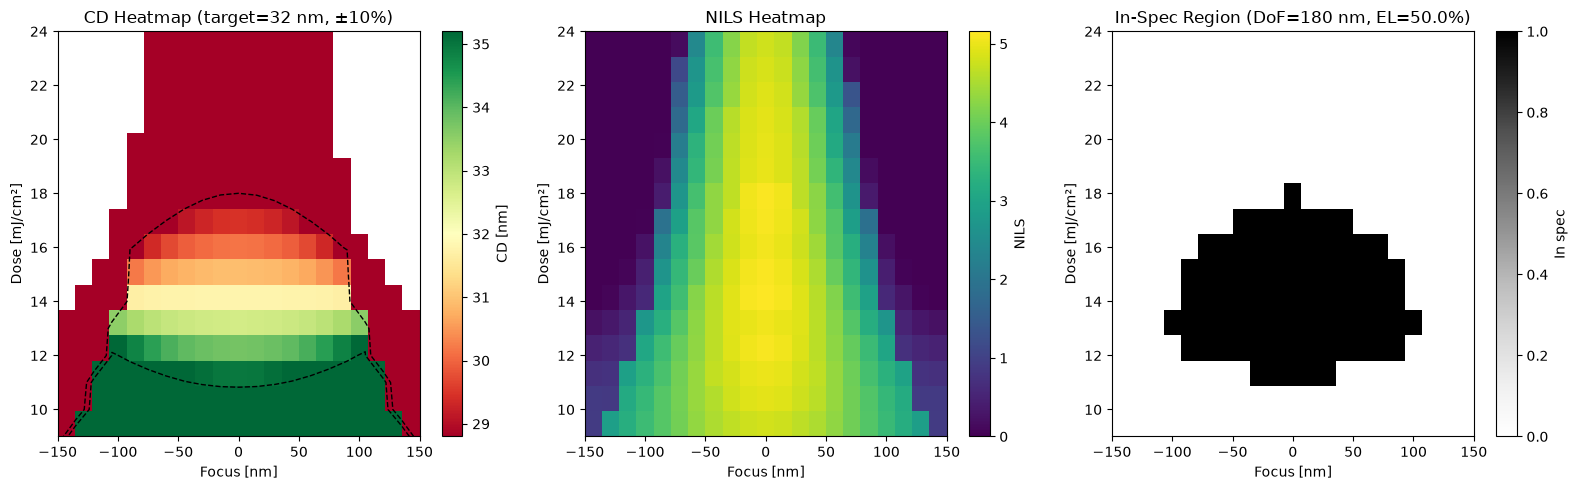

In [6]:
cd_low = TARGET_CD * (1 - tolerance)
cd_high = TARGET_CD * (1 + tolerance)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im1 = axes[0].imshow(
    cd_mat.T, origin="lower", aspect="auto",
    extent=[focuses[0], focuses[-1], doses[0], doses[-1]],
    cmap="RdYlGn", vmin=cd_low, vmax=cd_high,
)
axes[0].set_xlabel("Focus [nm]")
axes[0].set_ylabel("Dose [mJ/cm²]")
axes[0].set_title(f"CD Heatmap (target={TARGET_CD:.0f} nm, ±{tolerance*100:.0f}%)")
axes[0].contour(focuses, doses, cd_mat.T, levels=[cd_low, cd_high],
                colors="k", linewidths=1, linestyles="--")
plt.colorbar(im1, ax=axes[0], label="CD [nm]")

im2 = axes[1].imshow(
    nils_mat.T, origin="lower", aspect="auto",
    extent=[focuses[0], focuses[-1], doses[0], doses[-1]],
    cmap="viridis",
)
axes[1].set_xlabel("Focus [nm]")
axes[1].set_ylabel("Dose [mJ/cm²]")
axes[1].set_title("NILS Heatmap")
plt.colorbar(im2, ax=axes[1], label="NILS")

in_spec = (cd_mat >= cd_low) & (cd_mat <= cd_high) & (~np.isnan(cd_mat))
im3 = axes[2].imshow(
    in_spec.T, origin="lower", aspect="auto",
    extent=[focuses[0], focuses[-1], doses[0], doses[-1]],
    cmap="Greys", vmin=0, vmax=1,
)
axes[2].set_xlabel("Focus [nm]")
axes[2].set_ylabel("Dose [mJ/cm²]")
axes[2].set_title(f"In-Spec Region (DoF={pw['dof_nm']:.0f} nm, EL={pw['el_pct']:.1f}%)")
plt.colorbar(im3, ax=axes[2], label="In spec")

plt.tight_layout()
plt.show()


## 7. Bossung Curves (CD vs Dose at Several Focus Settings)


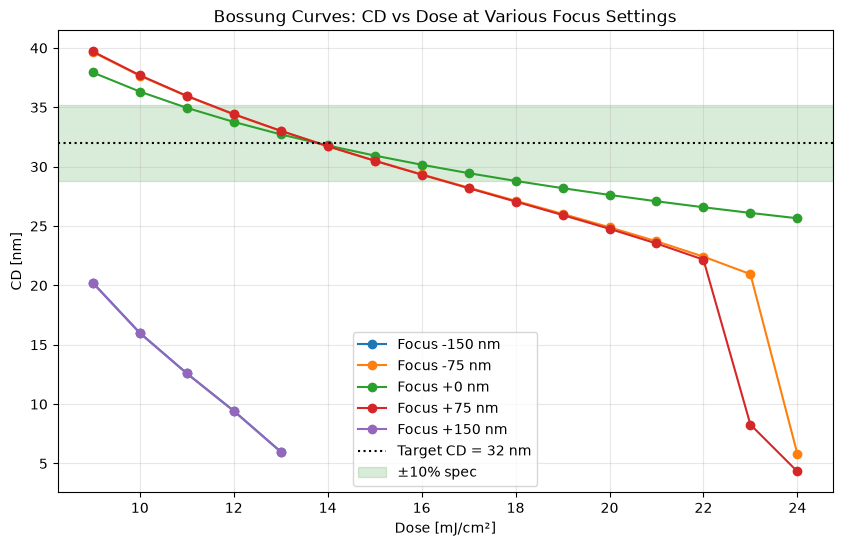

In [7]:
focus_indices = [0, len(focuses)//4, len(focuses)//2, 3*len(focuses)//4, -1]

plt.figure(figsize=(10, 6))
for idx in focus_indices:
    plt.plot(doses, cd_mat[idx, :], "o-", label=f"Focus {focuses[idx]:+.0f} nm")

plt.axhline(TARGET_CD, color="k", linestyle=":", label=f"Target CD = {TARGET_CD:.0f} nm")
plt.axhspan(cd_low, cd_high, alpha=0.15, color="green", label=f"±{tolerance*100:.0f}% spec")
plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("CD [nm]")
plt.title("Bossung Curves: CD vs Dose at Various Focus Settings")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Focus Dependence at Best Dose


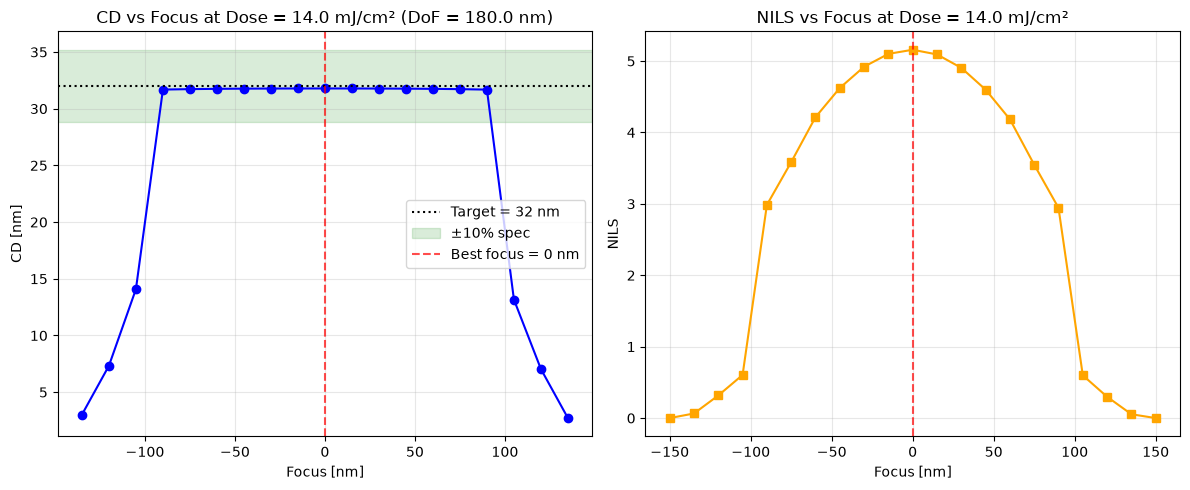

In [8]:
best_focus_row = int(np.argmin(np.abs(focuses - pw["best_focus"])))
best_dose_idx = int(np.nanargmin(np.abs(cd_mat[best_focus_row, :] - TARGET_CD)))
best_dose_val = doses[best_dose_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(focuses, cd_mat[:, best_dose_idx], "o-", color="blue")
ax1.axhline(TARGET_CD, color="k", linestyle=":", label=f"Target = {TARGET_CD:.0f} nm")
ax1.axhspan(cd_low, cd_high, alpha=0.15, color="green", label=f"±{tolerance*100:.0f}% spec")
ax1.axvline(pw["best_focus"], color="red", linestyle="--", alpha=0.7,
            label=f"Best focus = {pw['best_focus']:.0f} nm")
ax1.set_xlabel("Focus [nm]")
ax1.set_ylabel("CD [nm]")
ax1.set_title(f"CD vs Focus at Dose = {best_dose_val:.1f} mJ/cm² (DoF = {pw['dof_nm']:.1f} nm)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(focuses, nils_mat[:, best_dose_idx], "s-", color="orange")
ax2.axvline(pw["best_focus"], color="red", linestyle="--", alpha=0.7)
ax2.set_xlabel("Focus [nm]")
ax2.set_ylabel("NILS")
ax2.set_title(f"NILS vs Focus at Dose = {best_dose_val:.1f} mJ/cm²")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. SE Blur and Exposure Latitude (Full Chemistry)

The `aerial_threshold` model used above thresholds the optical image and ignores `se_blur_nm`, so
SE blur cannot change its process window. The full chemistry chain applies the SE blur to the
absorbed dose. Here the exposure latitude at best focus is computed with it for several SE blurs
(grid 128, dose-to-size by bisection, 25 doses within −26 %…+35 % of it, ±10 % CD tolerance).

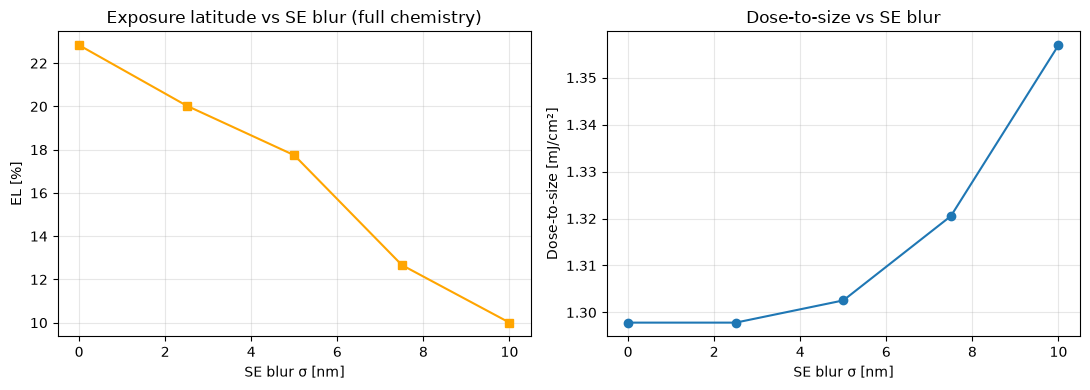

SE blur  0.0 nm: dose-to-size 1.298 mJ/cm², EL  22.8 %
SE blur  2.5 nm: dose-to-size 1.298 mJ/cm², EL  20.0 %
SE blur  5.0 nm: dose-to-size 1.303 mJ/cm², EL  17.7 %
SE blur  7.5 nm: dose-to-size 1.321 mJ/cm², EL  12.7 %
SE blur 10.0 nm: dose-to-size 1.357 mJ/cm², EL  10.0 %


In [9]:
def cd_full(dose, blur):
    cfg = SimulationConfig(
        period_nm=64.0, line_width_nm=TARGET_CD, dose_mj_cm2=float(dose),
        grid=128, se_blur_nm=float(blur), resist_model="full_chem",
    )
    return run_simulation(cfg).cd_nm

def dose_to_size(blur, lo=0.3, hi=10.0):
    for _ in range(14):
        mid = np.sqrt(lo * hi)
        if cd_full(mid, blur) > TARGET_CD:
            lo = mid
        else:
            hi = mid
    return np.sqrt(lo * hi)

se_blurs = [0.0, 2.5, 5.0, 7.5, 10.0]
d2s_blur, el_blur = [], []
for blur in se_blurs:
    d0 = dose_to_size(blur)
    ds = d0 * np.exp(np.linspace(-0.3, 0.3, 25))
    cds_b = np.array([cd_full(d, blur) for d in ds])
    ok = (cds_b >= cd_low) & (cds_b <= cd_high)
    el = 100.0 * (ds[ok].max() - ds[ok].min()) / d0 if ok.any() else 0.0
    d2s_blur.append(d0)
    el_blur.append(el)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(se_blurs, el_blur, "s-", color="orange")
ax1.set_xlabel("SE blur σ [nm]"); ax1.set_ylabel("EL [%]")
ax1.set_title("Exposure latitude vs SE blur (full chemistry)"); ax1.grid(True, alpha=0.3)
ax2.plot(se_blurs, d2s_blur, "o-")
ax2.set_xlabel("SE blur σ [nm]"); ax2.set_ylabel("Dose-to-size [mJ/cm²]")
ax2.set_title("Dose-to-size vs SE blur"); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for b, d0, e in zip(se_blurs, d2s_blur, el_blur):
    print(f"SE blur {b:4.1f} nm: dose-to-size {d0:.3f} mJ/cm², EL {e:5.1f} %")

## 10. NA Dependence of the Process Window

Higher NA improves resolution but narrows the depth of focus.


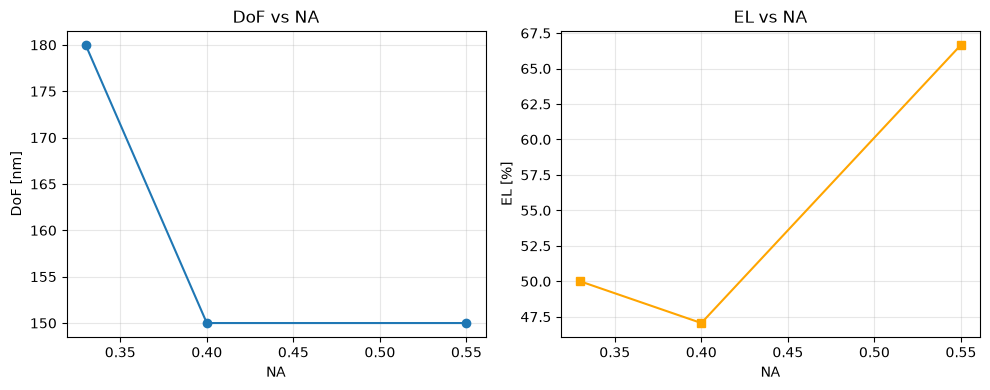

NA=0.33: DoF=180.0 nm, EL=50.0%
NA=0.40: DoF=150.0 nm, EL=47.1%
NA=0.55: DoF=150.0 nm, EL=66.7%


In [10]:
nas = [0.33, 0.40, 0.55]
dofs_na, els_na = [], []

for na in nas:
    def pipeline_fn_na(dose_mj_cm2, focus_nm):  # names dose_matrix passes
        cfg = SimulationConfig(
            period_nm=64.0, line_width_nm=TARGET_CD,
            dose_mj_cm2=dose_mj_cm2, focus_nm=focus_nm,
            grid=256, se_blur_nm=5.0, na=na, resist_model="aerial_threshold",
        )
        r = run_simulation(cfg)
        cd = r.cd_nm if r.cd_nm > 0 else np.nan
        return {"cd_nm": cd}

    cd_na = dose_matrix(pipeline_fn_na, doses.tolist(), focuses.tolist(), TARGET_CD, tolerance)
    if np.all(np.isnan(cd_na)):
        dofs_na.append(0.0)
        els_na.append(0.0)
        continue
    pw_na = process_window(cd_na, doses.tolist(), focuses.tolist(), TARGET_CD, tolerance)
    dofs_na.append(pw_na["dof_nm"])
    els_na.append(pw_na["el_pct"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(nas, dofs_na, "o-")
ax1.set_xlabel("NA"); ax1.set_ylabel("DoF [nm]")
ax1.set_title("DoF vs NA"); ax1.grid(True, alpha=0.3)

ax2.plot(nas, els_na, "s-", color="orange")
ax2.set_xlabel("NA"); ax2.set_ylabel("EL [%]")
ax2.set_title("EL vs NA"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for na, d, e in zip(nas, dofs_na, els_na):
    print(f"NA={na:.2f}: DoF={d:.1f} nm, EL={e:.1f}%")

## 11. MEEF — Mask Error Enhancement Factor

$$MEEF = \frac{\Delta CD_{wafer}}{\Delta CD_{mask}}$$

(mask CD in wafer units, i.e. already divided by the 4× demagnification). The `aerial_threshold`
model places its threshold relative to the mean intensity of the image, and that mean changes when
the mask CD changes, so the threshold moves with the mask and MEEF comes out too small. MEEF is
therefore computed with the full chemistry at its dose-to-size, and the threshold-model value is
shown next to it for comparison (mask CD 32 → 33 nm).

In [11]:
def cd_at(model, mask_cd, dose):
    cfg = SimulationConfig(
        period_nm=64.0, line_width_nm=mask_cd, dose_mj_cm2=dose,
        grid=256, resist_model=model,
    )
    return run_simulation(cfg).cd_nm

def compute_meef(model, dose, mask_cd=32.0, delta_mask=1.0):
    cd_nom = cd_at(model, mask_cd, dose)
    cd_pert = cd_at(model, mask_cd + delta_mask, dose)
    return (cd_pert - cd_nom) / delta_mask, cd_nom, cd_pert

meef, cd_nom, cd_pert = compute_meef("full_chem", dose=1.298)          # full-chemistry dose-to-size
meef_thr, cd_nom_thr, cd_pert_thr = compute_meef("aerial_threshold", dose=13.76)

print(f"MEEF (full chemistry):       {meef:.3f}   CD {cd_nom:.2f} → {cd_pert:.2f} nm")
print(f"MEEF (threshold model):      {meef_thr:.3f}   CD {cd_nom_thr:.2f} → {cd_pert_thr:.2f} nm  (biased low)")

MEEF (full chemistry):       1.278   CD 31.92 → 33.20 nm
MEEF (threshold model):      0.504   CD 32.00 → 32.51 nm  (biased low)


## 12. Export (CSV + Metrics)

The CLI equivalent: `euv process-window --period=64 --cd=32 --output-plot=pw.png --output-csv=pw.csv`.


In [12]:
import csv, json

with open("process_window_cd.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([""] + [f"{d:.1f}" for d in doses])
    for j, fc in enumerate(focuses):
        writer.writerow([f"{fc:.0f}"] + [f"{cd_mat[j, i]:.2f}" for i in range(len(doses))])

with open("process_window_metrics.json", "w") as f:
    json.dump({
        "target_cd_nm": TARGET_CD,
        "tolerance_pct": tolerance * 100,
        "dof_nm": pw["dof_nm"],
        "el_pct": pw["el_pct"],
        "best_dose": pw["best_dose"],
        "best_focus": pw["best_focus"],
        "meef": meef,
    }, f, indent=2)

print("✅ Exported process_window_cd.csv and process_window_metrics.json")


✅ Exported process_window_cd.csv and process_window_metrics.json


## Summary

| Metric | Meaning |
|--------|---------|
| **DoF** | Focus range where CD stays in spec |
| **EL** | Dose range where CD stays in spec |
| **MEEF** | Mask CD error amplification factor |
| **DoF × EL** | Process window area (figure of merit) |

**Key insights:**
- Blur shrinks the process window: in the full chemistry the exposure latitude falls from 22.8 %
  without SE blur to 10.0 % at 10 nm. At the default 2.5 nm it is 20.0 %, because the PEB acid
  diffusion (σ ≈ 7.9 nm) dominates the total blur.
- NA at 64 nm pitch (threshold model, 15 nm focus steps): DoF 180 nm at NA 0.33 and 150 nm at
  0.40 and 0.55; EL 50 %, 47 % and 67 %. At this pitch the higher NA mainly buys contrast; the
  DoF loss between 0.40 and 0.55 is below the focus step.
- MEEF is 1.28 in the full chemistry at 64/32 nm, so mask errors are slightly magnified. The
  threshold model gives 0.50 because its threshold follows the image mean (README, Known
  limitations).

**Next steps:**
- `euv process-window --period=64 --cd=32 --output-plot=pw.png --output-csv=pw.csv`
- Calibrate resist parameters against experimental Bossung data (`euv calibrate`)
- Explore illumination shapes (dipole, quasar) for process-window optimisation
